In [29]:
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

In [30]:
features = pd.read_csv("../data/customer_features_lowie1.csv")
train = pd.read_csv("../data/customer_clv_train.csv")

df = train.merge(features, on="cust_id", how="left")

In [31]:
churn_lgb = joblib.load("../models/lowie1_churn_lgb_model.pkl")
churn_xgb = joblib.load("../models/lowie1_churn_xgb_model.pkl")
churn_cat = joblib.load("../models/lowie1_churn_cat_model.pkl")
churn_rf  = joblib.load("../models/lowie1_churn_rf_model.pkl")

iso_lgb = joblib.load("../models/lowie1_iso_lgb.pkl")
iso_xgb = joblib.load("../models/lowie1_iso_xgb.pkl")
iso_cat = joblib.load("../models/lowie1_iso_cat.pkl")
iso_rf  = joblib.load("../models/lowie1_iso_rf.pkl")

def predict_churn_proba(X):
    p_lgb = iso_lgb.transform(churn_lgb.predict_proba(X)[:, 1])
    p_xgb = iso_xgb.transform(churn_xgb.predict_proba(X)[:, 1])
    p_cat = iso_cat.transform(churn_cat.predict_proba(X)[:, 1])
    p_rf  = iso_rf.transform(churn_rf.predict_proba(X)[:, 1])
    return (p_lgb + p_xgb + p_cat + p_rf) / 4

In [32]:
feature_cols = joblib.load("../models/lowie1_feature_columns.pkl")

In [33]:
# 60% train, 20% threshold optimalisatie, 20% finale validatie
df_trainval, df_val = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_thresh = train_test_split(df_trainval, test_size=0.25, random_state=42)
print(f"Train: {len(df_train)}  Thresh: {len(df_thresh)}  Val: {len(df_val)}")

p_return_val = predict_churn_proba(df_val[feature_cols])

df_return_train = df_train[df_train["revenue_2018_2019"] > 0].copy()
X_rev_train = df_return_train[feature_cols]
y_rev_train = np.log1p(df_return_train["revenue_2018_2019"])

Train: 69954  Thresh: 23318  Val: 23319


# LightGBM

In [34]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_rev_train, y_rev_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005386 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11369
[LightGBM] [Info] Number of data points in the train set: 25600, number of used features: 71
[LightGBM] [Info] Start training from score 4.903166


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,1200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


# XGBoost

In [35]:
xgb_model = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mae",
    random_state=42
)

xgb_model.fit(X_rev_train, y_rev_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

# CatBoost

In [36]:
cat_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    loss_function="MAE",
    verbose=False,
    random_state=42
)

cat_model.fit(X_rev_train, y_rev_train)

CatBoostRegressor(depth=6, iterations=800, learning_rate=0.03, loss_function='MAE', random_state=42, verbose=False)

# RANDOM FOREST

In [37]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=8
)
rf_model.fit(X_rev_train, y_rev_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl


# Comparison & Threshold Optimazation

In [38]:
p_return_thresh = predict_churn_proba(df_thresh[feature_cols])

best_overall_mae = 1000
best_threshold = 0
rev_model = None
best_model_name = None

for name, model in [("LightGBM", lgb_model), ("XGBoost", xgb_model), 
                    ("CatBoost", cat_model), ("RandomForest", rf_model)]:
    
    # Threshold optimalisatie op df_thresh — apart van df_val
    log_preds_thresh = model.predict(df_thresh[feature_cols])
    rev_preds_thresh = np.expm1(log_preds_thresh)
    
    best_corr, best_t, best_mae = -1, 0, 1000
    for t in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 
              0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
        preds = np.where(p_return_thresh < t, 0, p_return_thresh * rev_preds_thresh)
        mae = mean_absolute_error(df_thresh["revenue_2018_2019"], preds)
        corr, _ = spearmanr(df_thresh["revenue_2018_2019"], preds)
        if mae < best_mae:
            best_corr, best_t, best_mae = corr, t, mae
    
    print(f"{name} - Thresh MAE: {best_mae:.2f}  Spearman: {best_corr:.4f}  Threshold: {best_t:.2f}")
    
    if best_mae < best_overall_mae:
        best_overall_mae = best_mae
        best_threshold = best_t
        rev_model = model
        best_model_name = name

print(f"\nBest model: {best_model_name}  Threshold: {best_threshold:.2f}")

# Finale validatie MAE op held-out df_val — enkel voor rapportage
log_preds_val = rev_model.predict(df_val[feature_cols])
rev_preds_val = np.expm1(log_preds_val)
final_val_preds = np.where(p_return_val < best_threshold, 0, p_return_val * rev_preds_val)
val_mae = mean_absolute_error(df_val["revenue_2018_2019"], final_val_preds)
val_corr, _ = spearmanr(df_val["revenue_2018_2019"], final_val_preds)
print(f"\nFinale MAE op held-out validatieset: {val_mae:.2f}  Spearman: {val_corr:.4f}")

LightGBM - Thresh MAE: 62.20  Spearman: 0.3967  Threshold: 0.55
XGBoost - Thresh MAE: 62.04  Spearman: 0.3976  Threshold: 0.55
CatBoost - Thresh MAE: 62.05  Spearman: 0.3978  Threshold: 0.55
RandomForest - Thresh MAE: 62.06  Spearman: 0.3978  Threshold: 0.55

Best model: XGBoost  Threshold: 0.55

Finale MAE op held-out validatieset: 62.56  Spearman: 0.4018


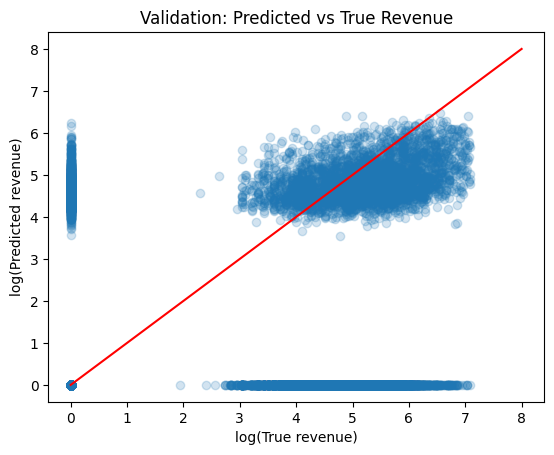

In [39]:
val_final_pred = np.where(
    p_return_val < best_threshold,
    0,
    p_return_val * np.expm1(rev_model.predict(df_val[feature_cols]))
)

plt.scatter(
    np.log1p(df_val["revenue_2018_2019"]),
    np.log1p(val_final_pred),
    alpha=0.2
)
plt.xlabel("log(True revenue)")
plt.ylabel("log(Predicted revenue)")
plt.plot([0, 8], [0, 8], "r")
plt.title("Validation: Predicted vs True Revenue")
plt.show()

In [40]:
# Consistentie-check: zijn de churn kansen stabiel?
print(f"\n--- Consistentie-check ---")
print(f"Gemiddelde churn kans (val):       {p_return_val.mean():.4f}")
print(f"Fractie voorspeld als returner:    {(p_return_val > best_threshold).mean():.4f}")
print(f"Werkelijke fractie returners:      {(df_val['revenue_2018_2019'] > 0).mean():.4f}")


--- Consistentie-check ---
Gemiddelde churn kans (val):       0.3649
Fractie voorspeld als returner:    0.1935
Werkelijke fractie returners:      0.3667


In [41]:
joblib.dump(best_threshold, "../models/lowie1_best_threshold.pkl")

['../models/lowie1_best_threshold.pkl']

# Save Revenue Model

In [42]:
joblib.dump(rev_model, "../models/lowie1_rev_model.pkl")

['../models/lowie1_rev_model.pkl']